# Exploratory Data Analysis (EDA) on Data Subset
This notebook performs basic Exploratory Data Analysis (EDA) on the sample dataset `diabetes_sample_raw.csv` using Pandas and Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Set style for visualizations
plt.style.use('ggplot')

# Load the sample dataset
df = pd.read_csv('../data/diabetes_sample_raw.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 25)


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'Over 60 years','Discharged to Home',Other,11,InternalMedicine,68,0,20,...,No,Yes,False,False,False,False,False,NO,0,0
1,Caucasian,Male,'30-60 years','Discharged to Home',Referral,1,Missing,20,0,7,...,No,Yes,False,False,False,False,False,NO,0,0
2,Caucasian,Female,'Over 60 years',Other,Referral,4,Missing,21,3,23,...,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Referral,12,Other,28,0,19,...,No,Yes,False,False,False,True,False,>30,1,0
4,AfricanAmerican,Female,'Over 60 years',Other,Emergency,1,Missing,21,0,6,...,No,Yes,False,False,False,False,False,<30,1,1


## Summary Statistics
Let's look at the basic statistics of the numeric clinical indicators.

In [2]:
df[['time_in_hospital', 'num_medications', 'num_lab_procedures']].describe()

,time_in_hospital,num_medications,num_lab_procedures
count,1000.000000,1000.000000,1000.000000
mean,4.393000,15.720000,43.889000
std,2.973785,7.927701,19.204987
min,1.000000,1.000000,1.000000
25%,2.000000,10.000000,33.000000
50%,4.000000,14.000000,45.000000
75%,6.000000,20.000000,58.000000
max,14.000000,60.000000,96.000000


## Demographic Distributions
Visualizing the balance of sensitive attributes (`race` and `gender`).

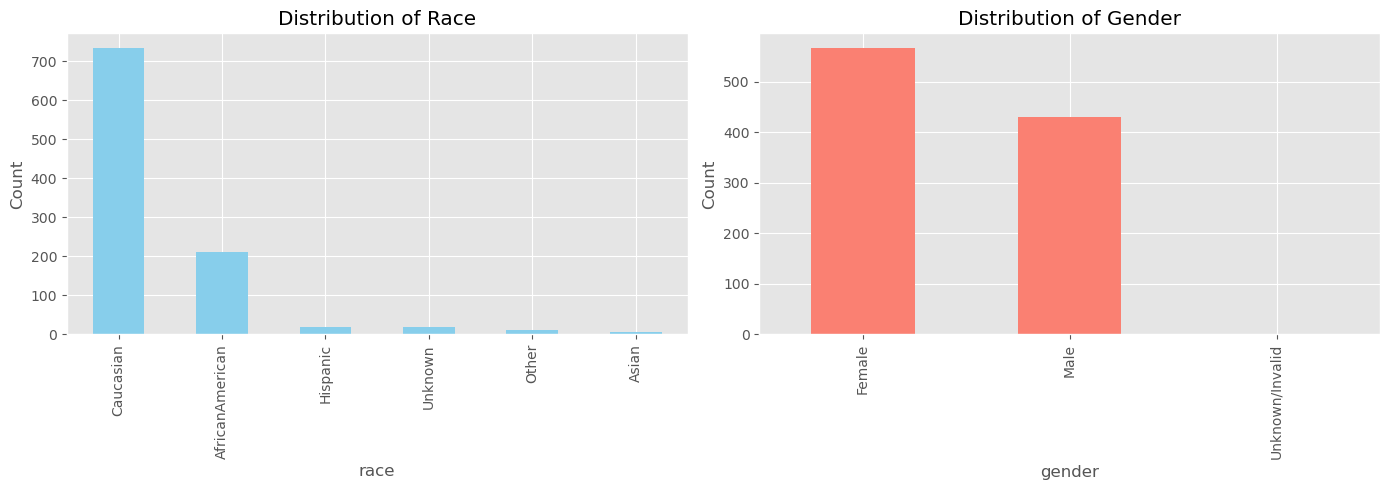

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Race Distribution
df['race'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Race')
axes[0].set_ylabel('Count')

# Gender Distribution
df['gender'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Additional Feature Distributions
Visualizing the distributions for `age`, `medicare`, and `medicaid`.

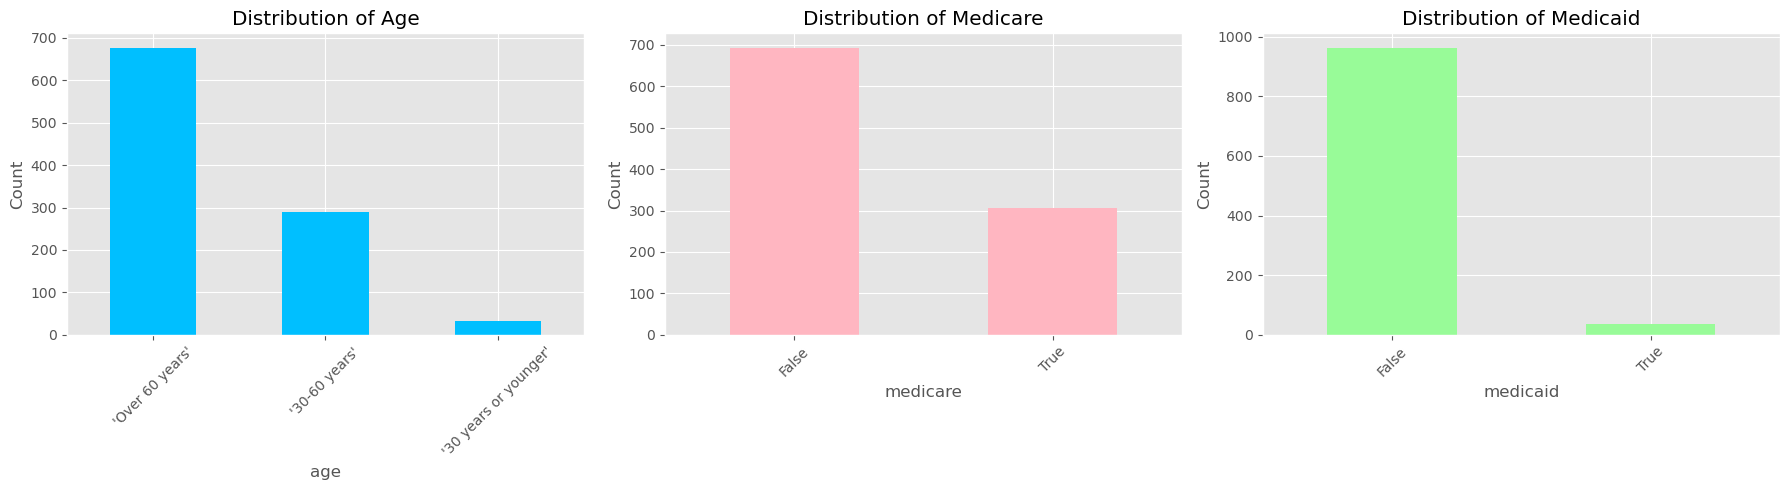

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['age', 'medicare', 'medicaid']
colors = ['deepskyblue', 'lightpink', 'palegreen']

for i, feature in enumerate(features):
    df[feature].value_counts().plot(kind='bar', ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {feature.capitalize()}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Target Variable Analysis (Readmissions)
How often are patients readmitted within 30 days across demographic groups?

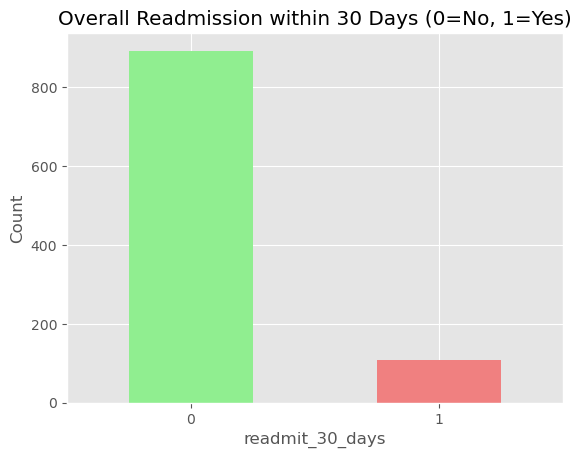

In [5]:
# Overall readmission distribution
readmit_counts = df['readmit_30_days'].value_counts()
readmit_counts.plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Overall Readmission within 30 Days (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

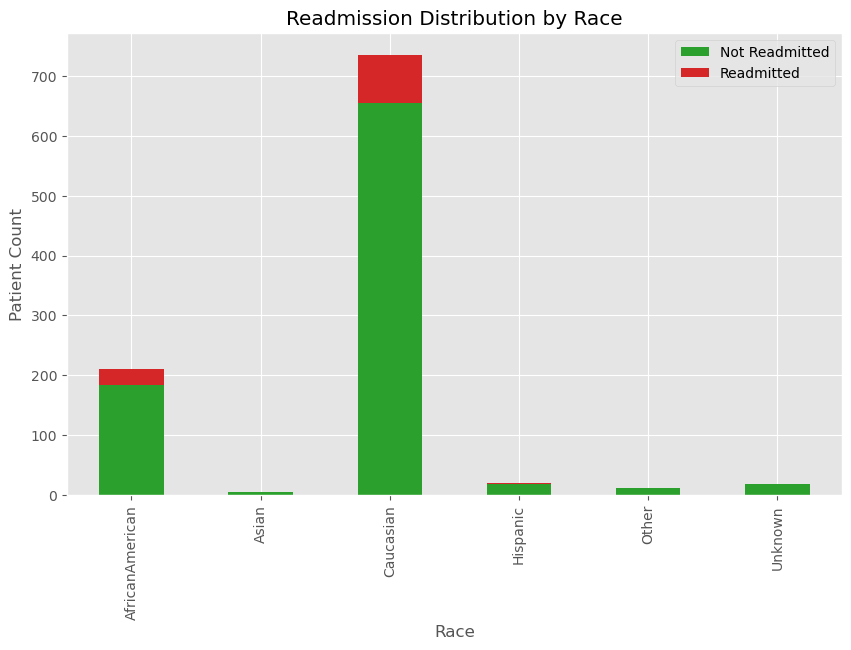

In [6]:
# Readmission by Race
race_readmit = df.groupby(['race', 'readmit_30_days']).size().unstack()
race_readmit.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.title('Readmission Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Patient Count')
plt.legend(['Not Readmitted', 'Readmitted'])
plt.show()